In [ ]:
# ===============================
# KO/PEP Pairs Trading Project
# ===============================

# Step 0: Install required package (run once)
# !pip install pandas-datareader statsmodels matplotlib

# Step 1: Import packages
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
from datetime import timedelta

# =============================== 
# Step 2: Download data
# ===============================

df = pd.read_csv("screened_pairs.csv")
df_sorted = df.sort_values(by = "coint_p_test")

s1 = "AMP"
s2 = "APO"
years = 4  # number of years to include

import datetime
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=365 * years)

s1data = yf.download(s1, start=start_date, end=end_date, auto_adjust=True)
s2data = yf.download(s2, start=start_date, end=end_date, auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
#df_sorted.head()


In [ ]:

s1_log = np.log(s1data['Close'].squeeze())
s2_log = np.log(s2data['Close'].squeeze())
s1_log.name = s1
s2_log.name = s2

s1_log, s2_log = s1_log.align(s2_log, join='inner')


In [ ]:

coint_t, p_value, _ = coint(s1_log, s2_log)
print(f"Cointegration p-value for {s1}/{s2} (last {years} years): {p_value:.4f}")

# Optional: inspect log prices
print("\nSample log prices:")
print(pd.concat([s1_log, s2_log], axis=1).head())

Cointegration p-value for AMP/APO (last 4 years): 0.0040

Sample log prices:
                 AMP       APO
Date                          
2022-06-28  5.438270  3.864540
2022-06-29  5.422725  3.833036
2022-06-30  5.413012  3.808585
2022-07-01  5.414231  3.824546
2022-07-05  5.402990  3.860631


In [ ]:
X = sm.add_constant(s2_log)  # independent variable
y = s1_log                   # dependent variable

model = sm.OLS(y, X).fit()
hedge_ratio = model.params[s2]
print(f"\nHedge ratio ({s1}/{s2}): {hedge_ratio:.4f}")

# Construct spread
spread = y - hedge_ratio * s2_log


Hedge ratio (AMP/APO): 0.6453


In [ ]:

spread_mean = spread.mean()
spread_std = spread.std()
zscore = (spread - spread_mean) / spread_std

signals = pd.DataFrame({
    f'{s1}_log': s1_log,
    f'{s2}_log': s2_log,
    'Spread': spread,
    'Zscore': zscore
})

print("\nSample spread and Z-score:")
print(signals.head())



Sample spread and Z-score:
             AMP_log   APO_log    Spread    Zscore
Date                                              
2022-06-28  5.438270  3.864540  2.944670 -1.314037
2022-06-29  5.422725  3.833036  2.949452 -1.220743
2022-06-30  5.413012  3.808585  2.955515 -1.102460
2022-07-01  5.414231  3.824546  2.946436 -1.279578
2022-07-05  5.402990  3.860631  2.911911 -1.953069


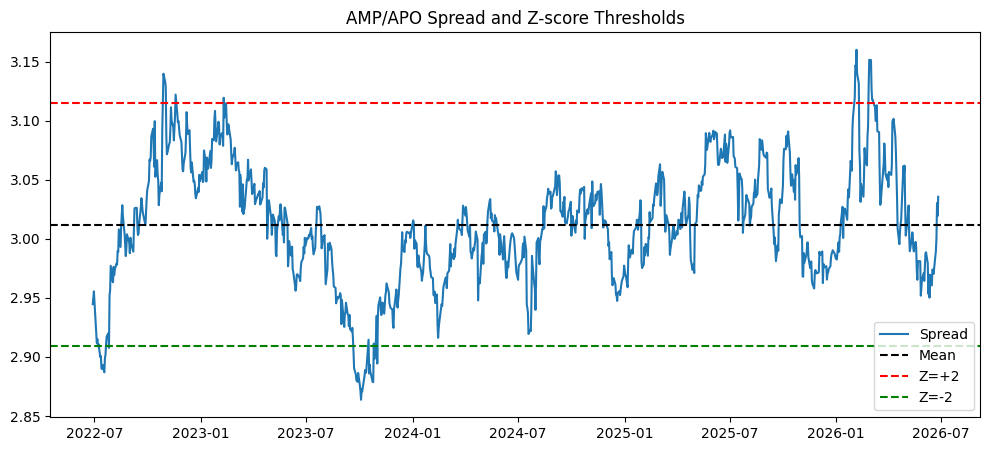

In [ ]:

# Plot spread and Z-score thresholds
threshold = 2 # number of sd at which we long/short

plt.figure(figsize=(12,5))
plt.plot(spread, label='Spread')
plt.axhline(spread_mean, color='black', linestyle='--', label='Mean')
plt.axhline(spread_mean + threshold*spread_std, color='red', linestyle='--', label=f'Z=+{threshold}')
plt.axhline(spread_mean - threshold*spread_std, color='green', linestyle='--', label=f'Z=-{threshold}')
plt.title(f'{s1}/{s2} Spread and Z-score Thresholds')
plt.legend()
plt.show()



In [ ]:

signals['long_entry'] = signals['Zscore'] < -threshold
signals['short_entry'] = signals['Zscore'] > threshold
signals['exit'] = signals['Zscore'].abs() < 0.5

# Iterate to correctly hold positions and respect exit signals
position = 0
positions = []
for _, row in signals.iterrows():
    if row['exit']:
        position = 0
    elif row['long_entry']:
        position = 1
    elif row['short_entry']:
        position = -1
    positions.append(position)
 
signals['position'] = positions


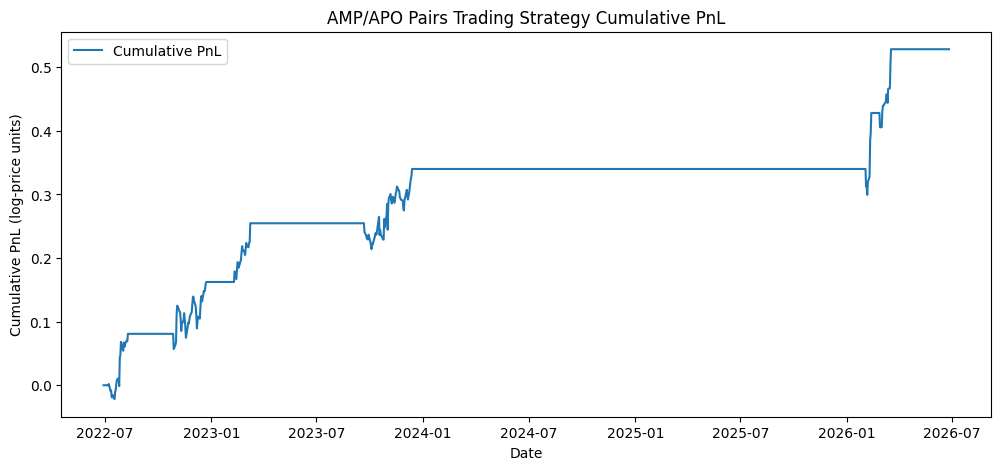

In [ ]:

# ===============================
# Step 9: Backtest PnL
# ===============================
spread_ret = signals['Spread'].diff()  # daily change in spread
signals['PnL'] = signals['position'].shift(1) * spread_ret
signals['Cumulative_PnL'] = signals['PnL'].cumsum()

# Plot cumulative PnL
plt.figure(figsize=(12,5))
plt.plot(signals['Cumulative_PnL'], label='Cumulative PnL')
plt.title(f'{s1}/{s2} Pairs Trading Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (log-price units)')
plt.legend()
plt.show()


In [ ]:

# ===============================
# Step 10: Optional performance metrics
# ===============================
sharpe = signals['PnL'].mean() / signals['PnL'].std() * np.sqrt(252)
num_trades = signals['position'].diff().abs().sum() / 2  # each round-trip counts as one trade

print(f"\nSharpe ratio: {sharpe:.2f}")
print(f"Number of trades: {num_trades}")



Sharpe ratio: 1.49
Number of trades: 6.0
